

---


# **Вступ**

Мета проєкту: аналіз трендів ринку праці Data Science в Індії (2025 рік)
Джерело даних: датасет вакансій із зазначенням зарплат, вимог до досвіду роботи та стеків навичок.
Обсяг вибірки: понад 7000 вакансій.

Датасет містить 7 колонок:
- Job Title - назва посади.
- Company Name - назва компанії (роботодавець).
- Location - локація (міста в Індії).
- Experience - досвід роботи, який вимагається.
- Salary - зарплатна вилка для вказаної посади.
- Job Description - опис роботи (графік, умови тощо).
- Skills - навички, що вимагаються.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data Science Job Market Project/Data_Science_Job_Market.csv')

Переглянемо перші 5 рядків датасету:

In [ ]:
df.head()

,Job Title,Company Name,Location,Experience,Salary,Job Description,Skills
0,Data Scientist,Uplers,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Python, TensorFlow, Computer Vision, Flink, Re..."
1,Business Analyst / Data Scientist,CBRE,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Data Visualization, Tableau, Analytics, Busine..."
2,Data Scientist - AI/ML,Trent Limited,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Artificial Intelligence, Machine Learning, Dat..."
3,Data Scientist,Fortune 500 IT Services Company,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,Not defined
4,Data Scientist,Foreign IT Consulting MNC,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,Not defined


Переглянемо інформацію про датасет в цілому:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7273 entries, 0 to 7272
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Job Title        7273 non-null   object
 1   Company Name     7272 non-null   object
 2   Location         7273 non-null   object
 3   Experience       7273 non-null   object
 4   Salary           7273 non-null   object
 5   Job Description  7273 non-null   object
 6   Skills           7273 non-null   object
dtypes: object(7)
memory usage: 397.9+ KB


Перевіримо наявність порожніх значень у датасеті:

In [ ]:
print(df.isnull().sum())

Job Title          0
Company Name       1
Location           0
Experience         0
Salary             0
Job Description    0
Skills             0
dtype: int64


Бачимо, що колонка "Company Name" має одне null-значення. Ми його замінимо на "Not defined".

In [ ]:
df['Company Name'] = df['Company Name'].fillna('Not defined')

In [ ]:
print(df.isnull().sum())

Job Title          0
Company Name       0
Location           0
Experience         0
Salary             0
Job Description    0
Skills             0
dtype: int64


Перевірили - порожнє значення усунено!

2. Якщо переглянути увесь датасет, ми бачимо багато значень "Not disclosed" у колонці з зарплатою. Це може спотворювати статистику, а отже, нам потрібно створити підтаблицю, яка міститиме конкретний діапазон зарплат.

In [ ]:
df_with_salary = df[(df['Salary'] != 'Not disclosed') & (df['Salary'] != 'Unpaid')].copy()


In [ ]:
df_with_salary

,Job Title,Company Name,Location,Experience,Salary,Job Description,Skills
0,Data Scientist,Uplers,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Python, TensorFlow, Computer Vision, Flink, Re..."
1,Business Analyst / Data Scientist,CBRE,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Data Visualization, Tableau, Analytics, Busine..."
2,Data Scientist - AI/ML,Trent Limited,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Artificial Intelligence, Machine Learning, Dat..."
3,Data Scientist,Fortune 500 IT Services Company,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,Not defined
4,Data Scientist,Foreign IT Consulting MNC,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,Not defined
...,...,...,...,...,...,...,...
7248,Data Engineer and AI Specialist,Sithafal Technologies,Bengaluru,2-4 Yrs,4-8 Lacs PA,Job Title: Data AnalystExperience: 2-3 yearsLo...,"Global marketing, nginx, Artificial Intelligen..."
7249,Data Analyst,Nbfc Credit Wise Capital,Bengaluru,2-4 Yrs,4-8 Lacs PA,Job Title: Data AnalystExperience: 2-3 yearsLo...,"Loans, Data analysis, digital analytics, NBFC,..."
7250,Data Governance Engineer,Aviatrix,Bengaluru,2-4 Yrs,4-8 Lacs PA,Job Title: Data AnalystExperience: 2-3 yearsLo...,"Data analysis, Automation, metadata, Networkin..."
7251,Programmer/Analyst,NetApp,Bengaluru,2-4 Yrs,4-8 Lacs PA,Job Title: Data AnalystExperience: 2-3 yearsLo...,"Order management, System testing, ERP, Data mi..."


3. Наступним кроком ми поділимо колонки з зарплатою та досвідом роботи на мінімальне і максимальне значення. У подальшому ми зможемо використовувати ці межі діапазонів для аналізу, не допускаючи помилок у обчисленнях.

In [ ]:

df_with_salary['is_monthly'] = df_with_salary['Salary'].str.contains('/month', case=False, na=False)
df_with_salary['is_crore'] = df_with_salary['Salary'].str.contains('Cr', case=False, na=False)

# витягуємо тільки цифри та дефіси
df_with_salary['clean_salary'] = df_with_salary['Salary'].str.replace(',', '').str.extract(r'([0-9\.-]+)')[0]
df_with_salary[['Min Salary', 'Max Salary']] = df_with_salary['clean_salary'].str.split('-', expand=True)
df_with_salary['Max Salary'] = df_with_salary['Max Salary'].fillna(df_with_salary['Min Salary'])

df_with_salary['Min Salary'] = df_with_salary['Min Salary'].astype(float)
df_with_salary['Max Salary'] = df_with_salary['Max Salary'].astype(float)

def adjust_min_salary(row):
    if row['is_monthly']:
        return (row['Min Salary'] * 12) / 100000
    elif row['is_crore']:
        return row['Min Salary'] * 100
    return row['Min Salary']

def adjust_max_salary(row):
    if row['is_monthly']:
        return (row['Max Salary'] * 12) / 100000
    elif row['is_crore']:
        return row['Max Salary'] * 100
    return row['Max Salary']

df_with_salary['Min Salary'] = df_with_salary.apply(adjust_min_salary, axis=1)
df_with_salary['Max Salary'] = df_with_salary.apply(adjust_max_salary, axis=1)

# функція для колонки "Досвід роботи"
df_with_salary['clean_exp'] = df_with_salary['Experience'].str.extract(r'([0-9-]+)')[0]
df_with_salary[['Min Experience', 'Max Experience']] = df_with_salary['clean_exp'].str.split('-', expand=True)
df_with_salary['Max Experience'] = df_with_salary['Max Experience'].fillna(df_with_salary['Min Experience'])

df_with_salary['Min Experience'] = df_with_salary['Min Experience'].astype(float)
df_with_salary['Max Experience'] = df_with_salary['Max Experience'].astype(float)

df_final = df_with_salary.drop(columns=['clean_salary', 'clean_exp', 'is_monthly', 'is_crore'])


In [ ]:
df_final.head()

,Job Title,Company Name,Location,Experience,Salary,Job Description,Skills,Min Salary,Max Salary,Min Experience,Max Experience
0,Data Scientist,Uplers,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Python, TensorFlow, Computer Vision, Flink, Re...",19.0,27.5,0.0,4.0
1,Business Analyst / Data Scientist,CBRE,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Data Visualization, Tableau, Analytics, Busine...",19.0,27.5,0.0,4.0
2,Data Scientist - AI/ML,Trent Limited,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,"Artificial Intelligence, Machine Learning, Dat...",19.0,27.5,0.0,4.0
3,Data Scientist,Fortune 500 IT Services Company,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,Not defined,19.0,27.5,0.0,4.0
4,Data Scientist,Foreign IT Consulting MNC,Hybrid - Bengaluru,0-4 Yrs,19-27.5 Lacs PA,Shift : 10:00AM to 7:00PM ISTBachelors / Maste...,Not defined,19.0,27.5,0.0,4.0




---


# **EDA (Розвідувальний аналіз даних)**

# 1. Кореляція між досвідом роботи та заробітною платнею.

Проведемо перше дослідження і перевіримо, ***як досвід роботи впливає на заробітну плату?***

/tmp/ipykernel_8441/1961995555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


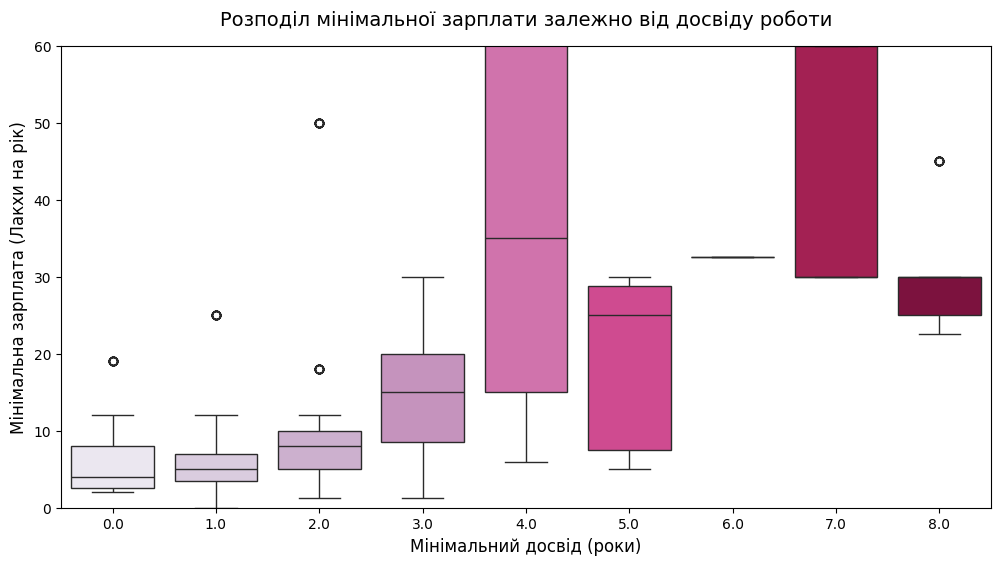

In [ ]:
plt.figure(figsize=(12, 6))

# Будуємо Boxplot зарплат для кожного рівня мінімального досвіду
sns.boxplot(
    data=df_final[df_final['Min Experience'] <= 8], # візьмемо досвід до 8 років для наочності
    x='Min Experience',
    y='Min Salary',
    palette='PuRd'
)

plt.ylim(0, 60) # фокусуємо вісь зарплат
plt.title('Розподіл мінімальної зарплати залежно від досвіду роботи', fontsize=14, pad=15)
plt.xlabel('Мінімальний досвід (роки)', fontsize=12)
plt.ylabel('Мінімальна зарплата (Лакхи на рік)', fontsize=12)

plt.show()

ВИСНОВОК: лінія тренду йду вгору, що доводить мою гіпотезу - чим вищі вимоги до досвіду роботи, тим вищу стартову зарплату пропонує ринок.

*Для кращого розуміння: я обрала датасет з вакансіями індійського ринку праці, тому
- 1 Лакх = 100 000 рупій;
- 1 долар = 83-85 індійських рупій;
- 1 Лакх = 1,200 доларів на рік.

Застосуємо статистику для відстеження кореляції між мінімальним рівнем досвіду та мінімальною зарплатнею.

Перевіримо розподіл зарплати та досвіду роботи на нормальність за допомогою методу Шапіро-Уілка:

In [ ]:
import scipy.stats as stats

In [ ]:
from scipy.stats import shapiro

df_stat = df_final[['Min Experience', 'Min Salary']].dropna()
stat, p = shapiro(df_stat['Min Salary'])
stat1, p1 = shapiro(df_stat['Min Experience'])

print(f"Перевірка нормальності розподілу для зарплати: {p}")
print(f"Перевірка нормальності розподілу для досвіду роботи: {p1}")

Перевірка нормальності розподілу для зарплати: 1.4986266252275934e-66
Перевірка нормальності розподілу для досвіду роботи: 9.620030827869925e-39


Оскільки p-value < 0.05, ми відхиляємо нормальність обох розподілів.

Для подальшого аналізу та знаходження коефіцієнту кореляції використовуємо метод Спірмена:

In [ ]:

# рахуємо кореляцію Спірмена та її p-value
spearman_corr, spearman_p = stats.spearmanr(df_stat['Min Experience'], df_stat['Min Salary'])

print(f"Коефіцієнт кореляції Спірмена: {spearman_corr:.3f} (p-value: {spearman_p})")

if spearman_corr > 0.5:
    strength = "сильний позитивний"
elif spearman_corr > 0.3:
    strength = "помірний позитивний"
else:
    strength = "слабкий"

if spearman_p < 0.05:
    significance = "зв'язок є статистично значущим (p < 0.05), тобто цей зв'язок не є випадковим"
else:
    significance = "зв'язок не є статистично НЕ значущим (p >= 0.05)"

print(f"Між мінімальним досвідом та стартовою зарплатою існує {strength} зв'язок ({spearman_corr:.2f}).")
print(f"Цей результат є {significance}.")

Коефіцієнт кореляції Спірмена: 0.681 (p-value: 8.853764538328121e-226)
Між мінімальним досвідом та стартовою зарплатою існує сильний позитивний зв'язок (0.68).
Цей результат є зв'язок є статистично значущим (p < 0.05), тобто цей зв'язок не є випадковим.


Отже, ймовірність 95% в тому, що існує вплив досвіду роботи на стартову позицію у зарплаті, і це не є випадковим збігом обставин.



---


# **2. Аналіз навичок за певними вакансіями**

Спершу проаналізуємо, ***які саме вакансії*** містить наш датасет.

Топ-10 вакансій у датасеті:


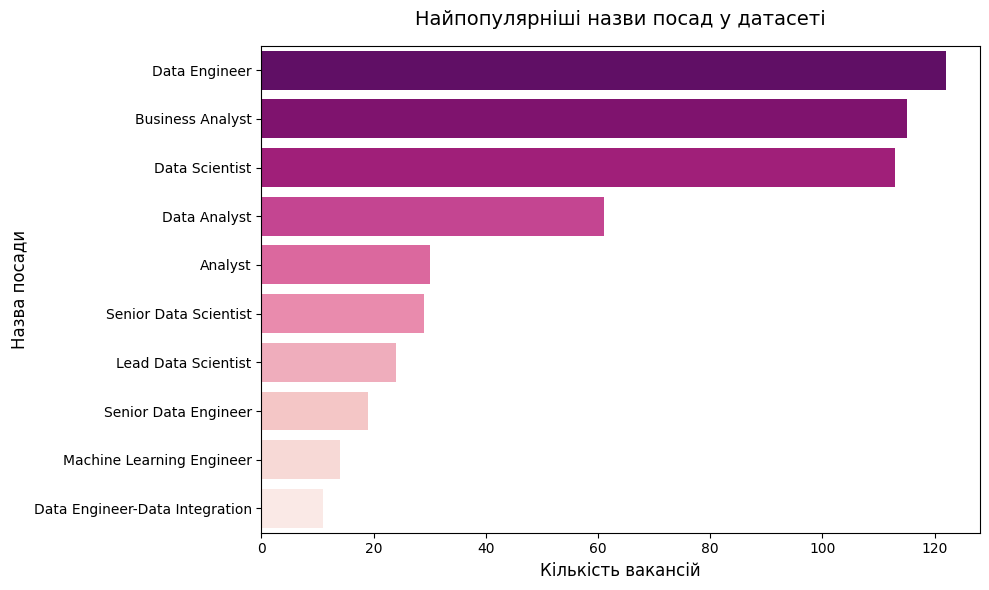

In [ ]:
job_titles_counts = df_final['Job Title'].value_counts()

print("Топ-10 вакансій у датасеті:")
plt.figure(figsize=(10, 6))
top_jobs = job_titles_counts.head(10)

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index,
    hue=top_jobs.index,
    palette='RdPu_r',
    legend=False
)

plt.title('Найпопулярніші назви посад у датасеті', fontsize=14, pad=15)
plt.xlabel('Кількість вакансій', fontsize=12)
plt.ylabel('Назва посади', fontsize=12)

plt.tight_layout()
plt.show()

Топ-3 посади є майже рівними по кількості вакансій у датасеті. Оскільки ми переконались, що кількості даних нам достатньо, ми можемо переходити до подальшого аналізу.

Я буду враховувати всі показник по основним посадам (Data Engineer, Data Analyst(Analyst), Business Analyst, Data Scientist). Для цього поділимо всі наявні вакансії по категоріям, і зробимо аналіз до кожної категорії окремо.

In [ ]:
def get_top_skills_clean(dataframe, top_n=10):
    skills_list = []

    # Список цих слів додаємо для їх ігнорування і додавання дійсних хард-скілів до списку
    stop_words = ['analytical', 'analytics', 'data analysis', 'data science', 'analyst',
        'not defined', 'data', 'business analysis', 'business analyst',
        'business analytics', 'analysis', 'data analyst', 'senior analyst',
        'data engineering', 'data quality', 'data management', 'data processing']

    synonyms_mapping = {
        'business analyst': 'business analysis',
        'business analytics': 'business analysis',
        'analysis': 'business analysis' if dataframe['Job Title'].str.contains('Business', case=False, na=False).any() else 'analysis'
    }

    for row in dataframe['Skills'].dropna():
        for skill in row.split(','):
            cleaned_skill = skill.strip().lower()

            if cleaned_skill in synonyms_mapping:
                cleaned_skill = synonyms_mapping[cleaned_skill]

            if cleaned_skill not in stop_words and cleaned_skill != '':
                skills_list.append(cleaned_skill)

    return pd.Series(skills_list).value_counts().head(top_n)

conditions = [
    # Категорія 1: Data Scientist + Senior/Lead + Machine Learning
    df_final['Job Title'].str.contains('Data Scientist|Machine Learning|ML|AI|Lead Data', case=False, na=False),

    # Категорія 2: Data Engineer + Senior + Data Integration
    df_final['Job Title'].str.contains('Engineer|ETL|Integration', case=False, na=False),

    # Категорія 3: Business Analyst
    df_final['Job Title'].str.contains('Business Analyst', case=False, na=False),

    # Категорія 4: Data Analyst та загальні аналітики
    df_final['Job Title'].str.contains('Analyst', case=False, na=False) & ~df_final['Job Title'].str.contains('Business|Engineer', case=False, na=False)
]

categories = ['Data Scientist', 'Data Engineer', 'Business Analyst', 'Data Analyst']

Profession
Data Scientist      629
Data Engineer       406
Other               277
Data Analyst        191
Business Analyst    152
Name: count, dtype: int64


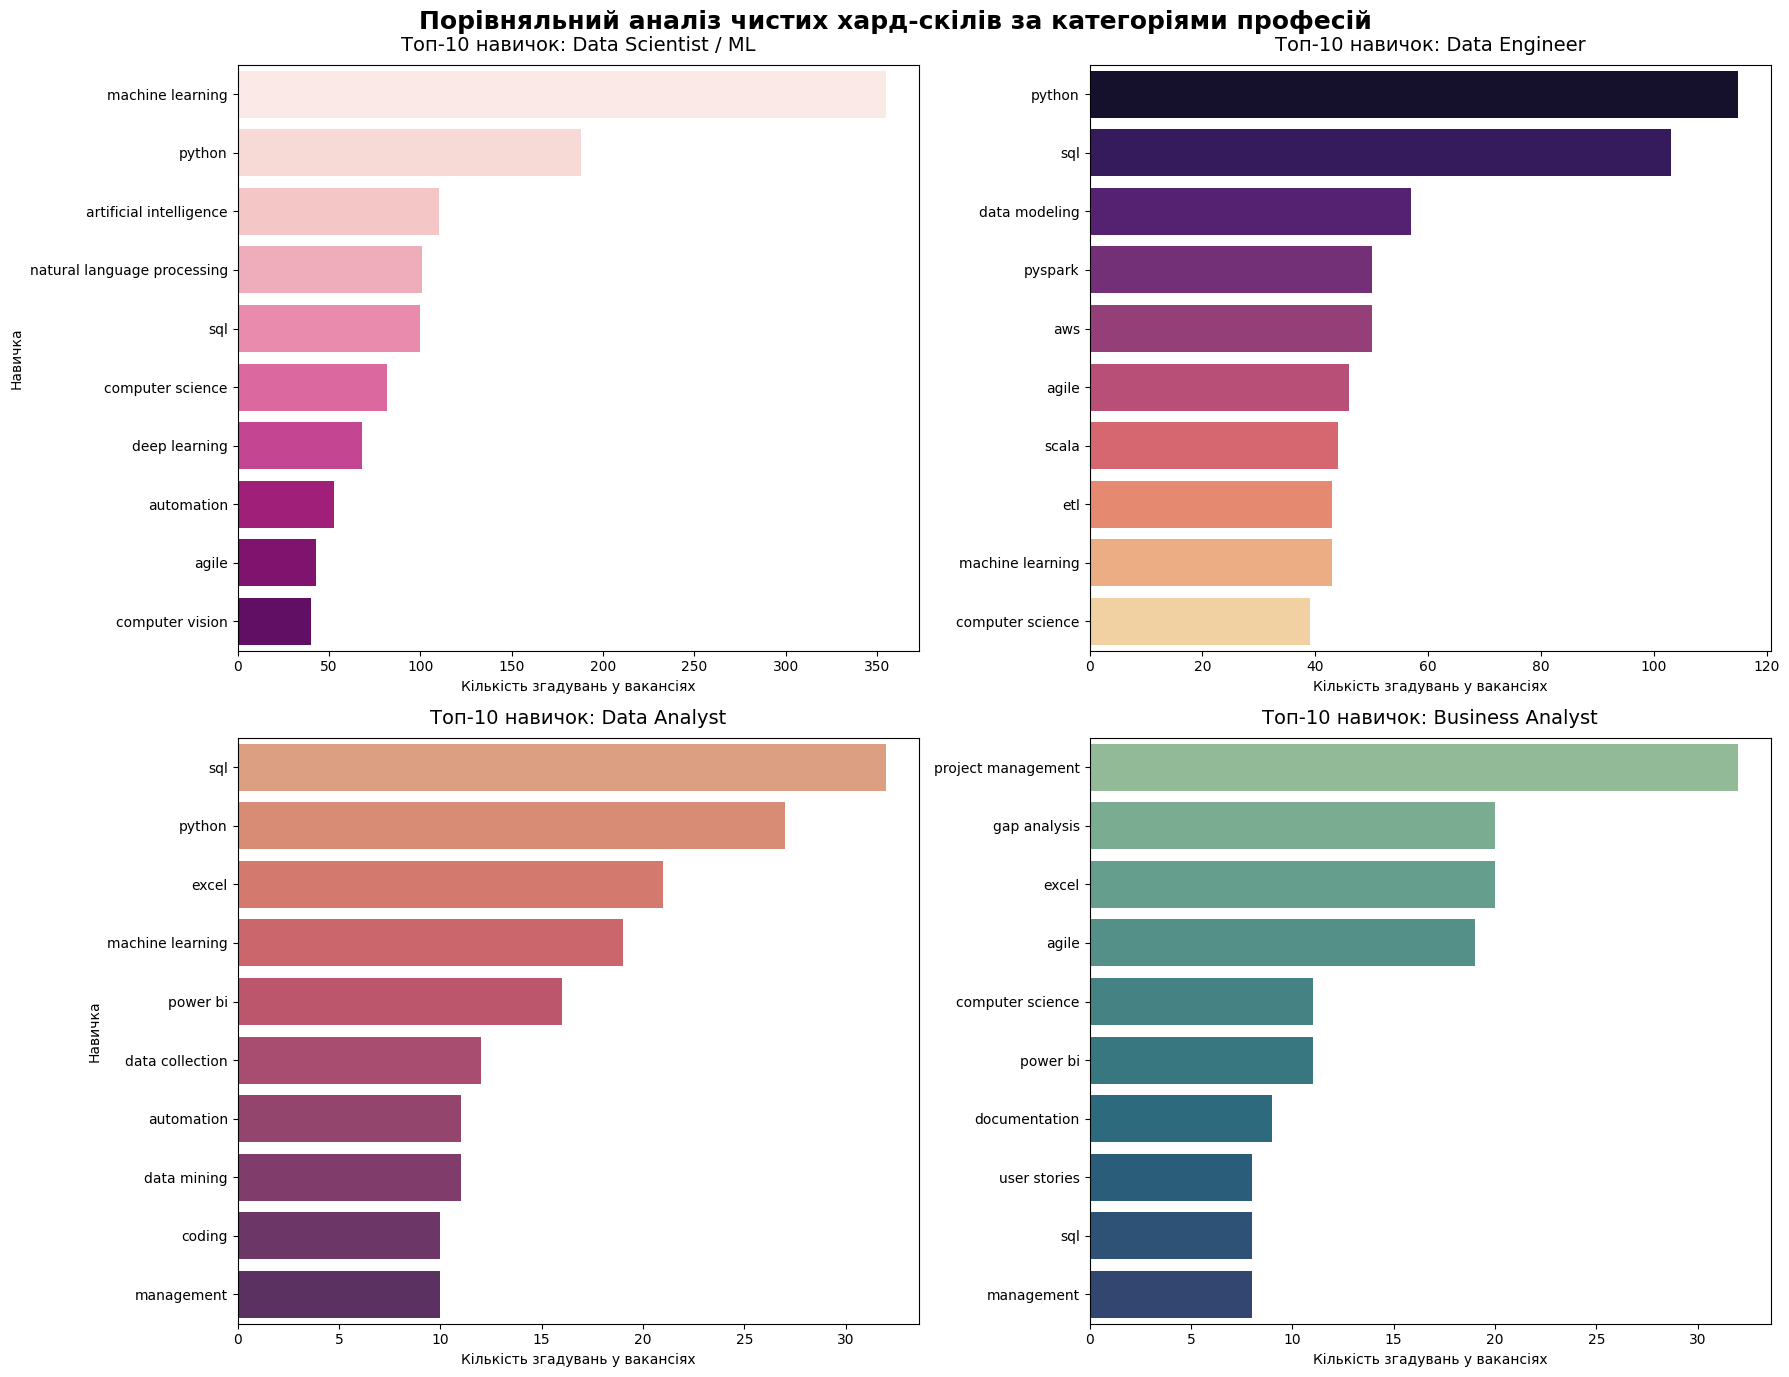

In [ ]:
df_final['Profession'] = np.select(conditions, categories, default='Other')

print(df_final['Profession'].value_counts())

ds_top = get_top_skills_clean(df_final[df_final['Profession'] == 'Data Scientist'])
de_top = get_top_skills_clean(df_final[df_final['Profession'] == 'Data Engineer'])
da_top = get_top_skills_clean(df_final[df_final['Profession'] == 'Data Analyst'])
ba_top = get_top_skills_clean(df_final[df_final['Profession'] == 'Business Analyst'])

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(x=ds_top.values, y=ds_top.index, hue=ds_top.index, palette='RdPu', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Топ-10 навичок: Data Scientist / ML', fontsize=14, pad=10)
axes[0, 0].set_xlabel('Кількість згадувань у вакансіях')
axes[0, 0].set_ylabel('Навичка')

sns.barplot(x=de_top.values, y=de_top.index, hue=de_top.index, palette='magma', ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Топ-10 навичок: Data Engineer', fontsize=14, pad=10)
axes[0, 1].set_xlabel('Кількість згадувань у вакансіях')
axes[0, 1].set_ylabel('')

sns.barplot(x=da_top.values, y=da_top.index, hue=da_top.index, palette='flare', ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Топ-10 навичок: Data Analyst', fontsize=14, pad=10)
axes[1, 0].set_xlabel('Кількість згадувань у вакансіях')
axes[1, 0].set_ylabel('Навичка')

sns.barplot(x=ba_top.values, y=ba_top.index, hue=ba_top.index, palette='crest', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Топ-10 навичок: Business Analyst', fontsize=14, pad=10)
axes[1, 1].set_xlabel('Кількість згадувань у вакансіях')
axes[1, 1].set_ylabel('')

plt.suptitle('Порівняльний аналіз чистих хард-скілів за категоріями професій', fontsize=18, weight='bold', y=0.98)

plt.tight_layout()
plt.show()

Отже, переглянувши графіки, можемо зробити висновки:
- SQL та Python залишаються фундаментальними інструментами на ринку даних. Даний стек присутній в топах майже кожної професії, тому це must-have для вивчення.
- для Data Engineer/Data Science фокус зміщений у бік моделювання даних та роботи з ШІ/машинним навчанням.
- для Data Analyst спеціалістів також є потреба у освоєні Excel та Power BI, які допомагають швидко перетворювати сирі дані на бізнес-звіти.
- Business ANalyst є найменш технічною роллю, тому найбільший фокус падає на проджект менеджмент, комунікацію та розуміння управління процесами, а серед інструментів лідирують ті самі Excel та Power BI.

3. Проведемо наступне дослідження та визначимо, які компанії найактивніше наймають працівників.

In [ ]:
df_companies = df_final['Company Name'].value_counts().head(10)

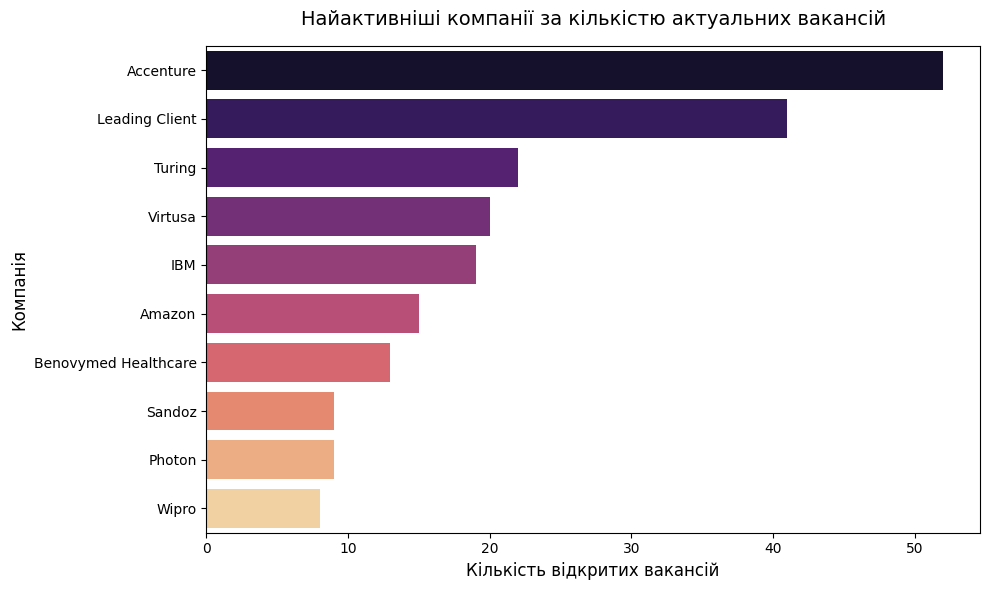

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=df_companies.values,
    y=df_companies.index,
    hue=df_companies.index,
    palette='magma',
    legend=False
)

plt.title('Найактивніші компанії за кількістю актуальних вакансій', fontsize=14, pad=15)
plt.xlabel('Кількість відкритих вакансій', fontsize=12)
plt.ylabel('Компанія', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
for prof in ['Data Scientist', 'Data Engineer', 'Data Analyst', 'Business Analyst']:
    prof_df = df_final[df_final['Profession'] == prof]
    leader = prof_df['Company Name'].value_counts().head(1)
    if not leader.empty:
        print(f"• {prof}: найкраще наймає компанія '{leader.index[0]}' ({leader.values[0]} вакансій)")

• Data Scientist: найкраще наймає компанія 'Turing' (14 вакансій)
• Data Engineer: найкраще наймає компанія 'Accenture' (18 вакансій)
• Data Analyst: найкраще наймає компанія 'Leading Client' (7 вакансій)
• Business Analyst: найкраще наймає компанія 'Accenture' (20 вакансій)


Accenture очолює даний рейтинг і має найбільшу кількість відкритих вакансій. За категоріями, вона наймає працівників на дві позиції: Data Engineer та Business Analyst.

4. Аналіз зарплат відповідно до позиції. ***Який саме аналітик отримує найбільший дохід на нинішньому ринку праці?***

/tmp/ipykernel_8441/1167408046.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_salary,


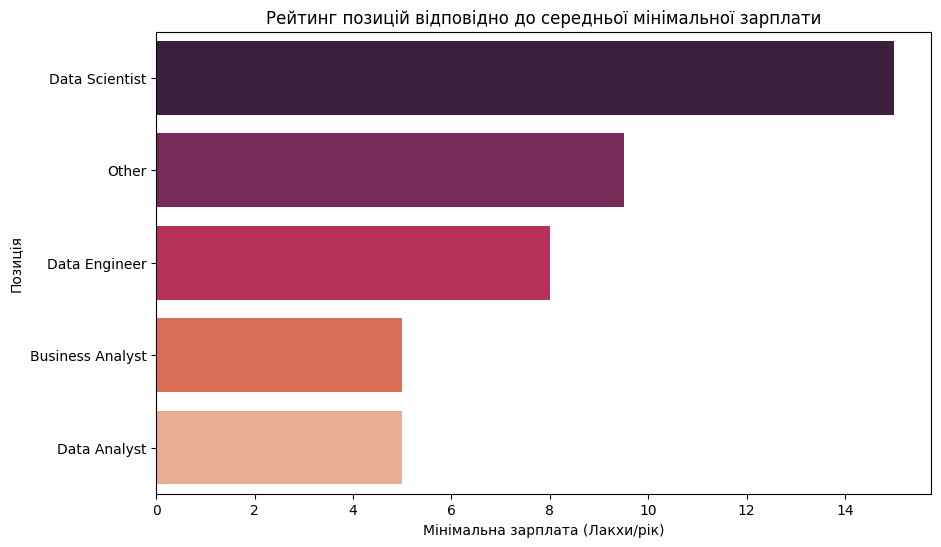

In [ ]:
avg_salary = df_final.groupby('Profession')['Min Salary'].median().sort_values(ascending=False).reset_index()
avg_salary

plt.figure(figsize=(10,6))
sns.barplot(data=avg_salary,
             x='Min Salary',
             y='Profession',
            palette='rocket')

plt.title('Рейтинг позицій відповідно до середньої мінімальної зарплати')
plt.xlabel('Мінімальна зарплата (Лакхи/рік)')
plt.ylabel('Позиція')
plt.show()



За результатами аналізу медіанного рівня зарплатні ми бачимо, що статистику значно випереджують Data Scientist - їх стартові фінансові пропозиції суттєво випереджають інші позиції. На другому місці опинилися фахівці з Data Engineering. Дата аналітики та бізнес аналітики мають однакові медіанні рівні зарплатні.
Для аналізу застосовували медіану, оскільки вона є стійкою до викидів, таких як наявність нульових значень зарплат (стажування) чи поодинокі надвисокі контракти та відображає реальну ситуацію на ринку праці.
Категорія 'Other' містить нетипові або керівні посади, тому має підвищений стартовий поріг